# Data Cleaning
This notebook is for cleaning the dataset in preperation for use in our various models.

## Import Packages

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [46]:
thyroid_df = pd.read_csv('Thyroid-Dataset.csv')
thyroid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9171 entries, 0 to 9170
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        9171 non-null   int64  
 1   sex                        8864 non-null   object 
 2   on thyroxine               9171 non-null   bool   
 3   query on thyroxine         9171 non-null   bool   
 4   on antithyroid medication  9171 non-null   bool   
 5   sick                       9171 non-null   bool   
 6   pregnant                   9171 non-null   bool   
 7   thyroid surgery            9171 non-null   bool   
 8   I131 treatment             9171 non-null   bool   
 9   query hypothyroid          9171 non-null   bool   
 10  query hyperthyroid         9171 non-null   bool   
 11  lithium                    9171 non-null   bool   
 12  goitre                     9171 non-null   bool   
 13  tumor                      9171 non-null   bool 

## Drop Refferal Source Column

In [47]:
thyroid_df = thyroid_df.drop(columns='referral source')

## Recast Sex Column as Category DType

In [48]:
thyroid_df['sex'] = thyroid_df['sex'].astype('category')

## Drop Rows with Age Errors

In [49]:
age_error_rows = thyroid_df[thyroid_df['age'] > 100]
thyroid_df = thyroid_df.drop(age_error_rows.index)

## Create Missing Data Flags for Float Variables

In [50]:
float_cols = thyroid_df.dtypes[thyroid_df.dtypes == 'float64'].index
for col in float_cols:
    new_col_name = col + '_missing'
    new_col_ind = thyroid_df.columns.to_list().index(col) + 1
    thyroid_df.insert(new_col_ind, new_col_name, False)

## Dummify Class Variable

In [51]:
thyroid_df = pd.concat([thyroid_df, pd.get_dummies(thyroid_df['class'])], axis=1)
thyroid_df = thyroid_df.drop(columns='class')

## Attempts at Imputation

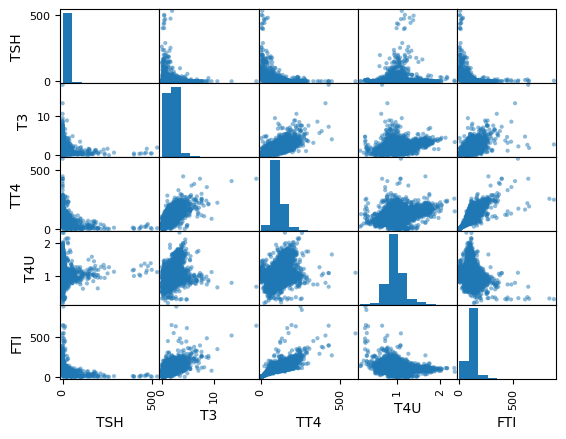

In [53]:
float_cols = thyroid_df.dtypes[thyroid_df.dtypes == 'float64'].index
pd.plotting.scatter_matrix(thyroid_df[float_cols])
plt.show()

### TSH

### T3

### TT4

### T4U

### FTI

### Sex